In [3]:
# Capstone Aim 2 

In [4]:
"""
Method A Paper
Title: Deep Learning for ECG Classification: A Comparative Study of 1D and 2D Representations and Multimodal Fusion Approaches
Authors: Hemaxi N. et al.
Published: 2024
Source: ScienceDirect
    

What We Implemented:
A 1D Convolutional Neural Network (CNN) for ECG classification, focused on:

Using raw time-series ECG signals (no image conversion)
Extracting local temporal features using Conv1D
Training with softmax for 5-class classification on ECG5000
Evaluation using accuracy, confusion matrix, and F1-score
This forms your Method A for Aim 2. Ready to move on to Method B implementation next?   

"""

'\nMethod A Paper\nTitle: Deep Learning for ECG Classification: A Comparative Study of 1D and 2D Representations and Multimodal Fusion Approaches\nAuthors: Hemaxi N. et al.\nPublished: 2024\nSource: ScienceDirect\n    \n\nWhat We Implemented:\nA 1D Convolutional Neural Network (CNN) for ECG classification, focused on:\n\nUsing raw time-series ECG signals (no image conversion)\nExtracting local temporal features using Conv1D\nTraining with softmax for 5-class classification on ECG5000\nEvaluation using accuracy, confusion matrix, and F1-score\nThis forms your Method A for Aim 2. Ready to move on to Method B implementation next?   \n\n'

In [5]:
#Preprocessing

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load ECG5000 train and test data
train_df = pd.read_csv("ECG5000/ECG5000_TRAIN.txt", delim_whitespace=True, header=None)
test_df = pd.read_csv("ECG5000/ECG5000_TEST.txt", delim_whitespace=True, header=None)

# Combine into a single dataset
df = pd.concat([train_df, test_df], ignore_index=True)

# Separate signals and labels
X = df.iloc[:, 1:].values  # 140 time steps per ECG signal
y = df.iloc[:, 0].values   # Labels: 1–5

# Convert labels to 0-indexed (0–4)
y = y - 1

# Normalize signals to [0, 1]
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Reshape to fit Conv1D input: (samples, time_steps, channels)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Split into train (60%), validation (20%), test (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)


print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (3000, 140, 1), Val: (1000, 140, 1), Test: (1000, 140, 1)


In [7]:
#Build 1D CNN Model (Method A)

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(140, 1)),  # First Conv1D layer
    MaxPooling1D(pool_size=2),
    
    Conv1D(128, 3, activation='relu'),  # Second Conv1D layer
    MaxPooling1D(pool_size=2),
    
    Flatten(),                         # Flatten before fully connected layers
    Dense(64, activation='relu'),      # Dense hidden layer
    Dropout(0.5),                      # Dropout for regularization
    Dense(5, activation='softmax')     # Output layer for 5 classes
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)



Epoch 1/30


/Users/akritisaxena/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6218 - loss: 0.9779 - val_accuracy: 0.9230 - val_loss: 0.3313
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9146 - loss: 0.3705 - val_accuracy: 0.9270 - val_loss: 0.2475
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9285 - loss: 0.3095 - val_accuracy: 0.9290 - val_loss: 0.2351
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9259 - loss: 0.2759 - val_accuracy: 0.9350 - val_loss: 0.2221
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9438 - loss: 0.2286 - val_accuracy: 0.9370 - val_loss: 0.2108
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9340 - loss: 0.2419 - val_accuracy: 0.9310 - val_loss: 0.2108
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9404 - loss: 0.2135 - val_accuracy: 0.9440 - val_loss: 0.2007
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9353 - loss: 0.2247 - val_accuracy: 0.9450 - val_loss: 0.1974
Epo

In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 138, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 69, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 67, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 33, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4224)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       270,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 887,057 (3.38 MB)

 Trainable params: 295,685 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 591,372 (2.26 MB)

In [9]:
#Evaluate Method A

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9633 - loss: 0.1464
Test Accuracy: 0.9550


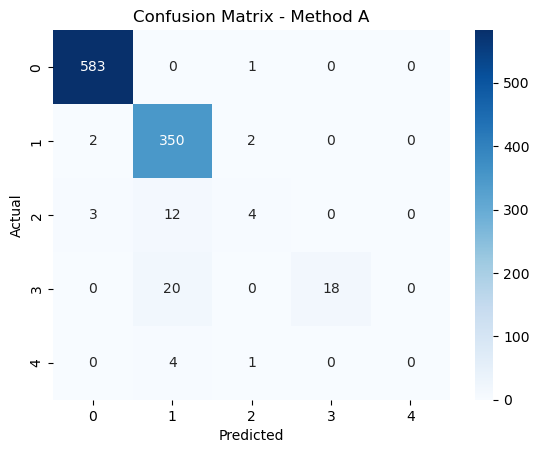

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict class probabilities and class labels
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix - Method A")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()




In [11]:
# Print classification report
print("Classification Report (Method A):")
print(classification_report(y_test, y_pred_classes, digits=4))


Classification Report (Method A):
              precision    recall  f1-score   support

         0.0     0.9915    0.9983    0.9949       584
         1.0     0.9067    0.9887    0.9459       354
         2.0     0.5000    0.2105    0.2963        19
         3.0     1.0000    0.4737    0.6429        38
         4.0     0.0000    0.0000    0.0000         5

    accuracy                         0.9550      1000
   macro avg     0.6796    0.5342    0.5760      1000
weighted avg     0.9475    0.9550    0.9459      1000



/Users/akritisaxena/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/akritisaxena/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/akritisaxena/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


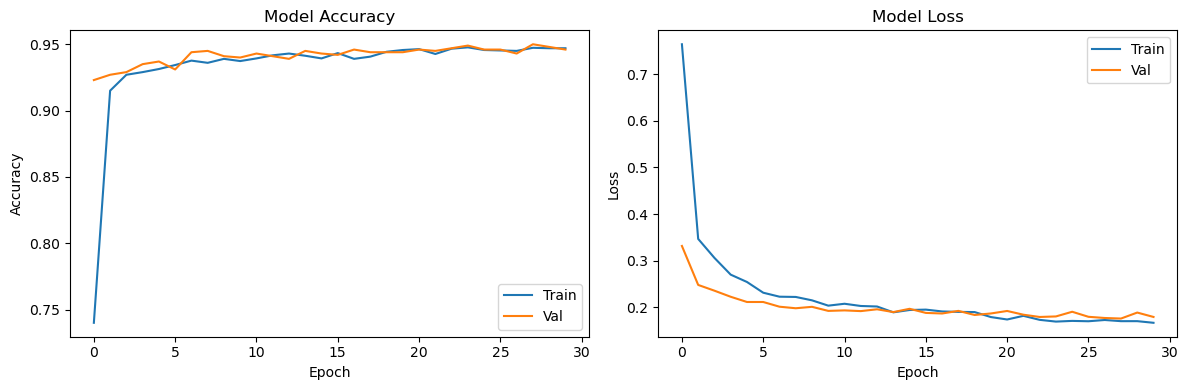

In [13]:
# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Train")
plt.plot(history.history['val_accuracy'], label="Val")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label="Train")
plt.plot(history.history['val_loss'], label="Val")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [8]:
"""
Method B: AlexNet-Inspired Dual Branch CNN
We'll base this on the paper:

Title: Classification of ECG signal using FFT based improved AlexNet classifier
Key Idea:

One branch handles raw time-domain ECG signals
Second branch handles frequency-domain (FFT-transformed) features
Both branches merge into a fully connected layer for classification
"""

"\nMethod B: AlexNet-Inspired Dual Branch CNN\nWe'll base this on the paper:\n\nTitle: Classification of ECG signal using FFT based improved AlexNet classifier\nKey Idea:\n\nOne branch handles raw time-domain ECG signals\nSecond branch handles frequency-domain (FFT-transformed) features\nBoth branches merge into a fully connected layer for classification\n"

In [14]:
#Preprocessing FFT Input

In [15]:
# Apply FFT to each ECG signal (magnitude only, real part)
X_fft = np.abs(np.fft.fft(X.squeeze(), axis=1))

# Keep only the first half of the spectrum (FFT is symmetric)
X_fft = X_fft[:, :X_fft.shape[1] // 2]

# Normalize the FFT-transformed signals
scaler_fft = MinMaxScaler()
X_fft = scaler_fft.fit_transform(X_fft)

# Reshape for CNN input: (samples, timesteps, 1)
X_fft = X_fft.reshape((X_fft.shape[0], X_fft.shape[1], 1))

# Re-split FFT features based on existing indices
X_fft_train, X_fft_temp = train_test_split(X_fft, test_size=0.4, random_state=42, stratify=y)
X_fft_val, X_fft_test = train_test_split(X_fft_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Confirm shapes
print("Time domain input shape:", X_train.shape)
print("Frequency domain input shape:", X_fft_train.shape)


Time domain input shape: (3000, 140, 1)
Frequency domain input shape: (3000, 70, 1)


In [16]:
#built Dual Branch CNN

In [17]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, concatenate

# Input for time-domain branch
input_time = Input(shape=(140, 1), name='time_input')
x1 = Conv1D(64, 3, activation='relu')(input_time)
x1 = MaxPooling1D(2)(x1)
x1 = Conv1D(128, 3, activation='relu')(x1)
x1 = MaxPooling1D(2)(x1)
x1 = Flatten()(x1)

# Input for frequency-domain branch (FFT)
input_freq = Input(shape=(70, 1), name='freq_input')
x2 = Conv1D(64, 3, activation='relu')(input_freq)
x2 = MaxPooling1D(2)(x2)
x2 = Conv1D(128, 3, activation='relu')(x2)
x2 = MaxPooling1D(2)(x2)
x2 = Flatten()(x2)

# Merge both branches
merged = concatenate([x1, x2])
merged = Dense(128, activation='relu')(merged)
merged = Dropout(0.5)(merged)
output = Dense(5, activation='softmax')(merged)

# Build and compile model
dual_cnn_model = Model(inputs=[input_time, input_freq], outputs=output)
dual_cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

dual_cnn_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ time_input          │ (None, 140, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ freq_input          │ (None, 70, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 138, 64)   │        256 │ time_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 68, 64)    │        256 │ freq_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 69, 64)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 34, 64)    │          0 │ conv1d_4[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 67, 128)   │     24,704 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 32, 128)   │     24,704 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 33, 128)   │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 16, 128)   │          0 │ conv1d_5[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 4224)      │          0 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2048)      │          0 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 6272)      │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    802,944 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │        645 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 853,509 (3.26 MB)

 Trainable params: 853,509 (3.26 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Early stopping to prevent overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history_dual = dual_cnn_model.fit(
    [X_train, X_fft_train], y_train,
    validation_data=([X_val, X_fft_val], y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6718 - loss: 0.8393 - val_accuracy: 0.9280 - val_loss: 0.2715
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9179 - loss: 0.3265 - val_accuracy: 0.9280 - val_loss: 0.2144
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9154 - loss: 0.2837 - val_accuracy: 0.9360 - val_loss: 0.2116
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9349 - loss: 0.2286 - val_accuracy: 0.9350 - val_loss: 0.1964
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9409 - loss: 0.2146 - val_accuracy: 0.9450 - val_loss: 0.1851
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9445 - loss: 0.1739 - val_accuracy: 0.9470 - val_loss: 0.1803
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9454 - loss: 0.1668 - val_accuracy: 0.9420 - val_loss: 0.1923
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9498 - loss: 0.1756 - val_accuracy: 0.9450 - val_loss:

In [19]:
# Evaluate Method B

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Test Accuracy (Method B): 0.9540


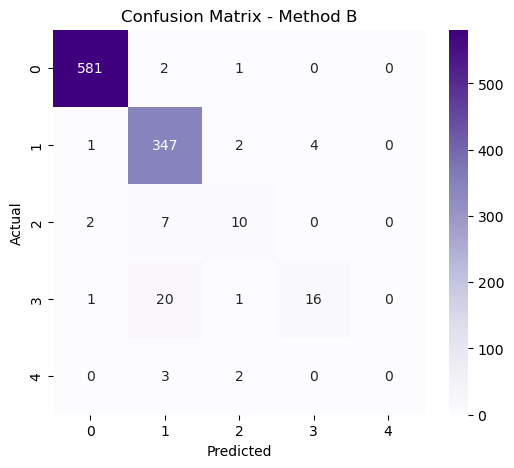

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on test set
y_pred_dual = dual_cnn_model.predict([X_test, X_fft_test])
y_pred_classes_dual = np.argmax(y_pred_dual, axis=1)

# Accuracy
test_loss, test_acc = dual_cnn_model.evaluate([X_test, X_fft_test], y_test, verbose=0)
print(f"\nTest Accuracy (Method B): {test_acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes_dual)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Method B")
plt.show()




In [21]:
# Classification Report
print("\nClassification Report (Method B):\n")
print(classification_report(y_test, y_pred_classes_dual, digits=4))


Classification Report (Method B):

              precision    recall  f1-score   support

         0.0     0.9932    0.9949    0.9940       584
         1.0     0.9156    0.9802    0.9468       354
         2.0     0.6250    0.5263    0.5714        19
         3.0     0.8000    0.4211    0.5517        38
         4.0     0.0000    0.0000    0.0000         5

    accuracy                         0.9540      1000
   macro avg     0.6667    0.5845    0.6128      1000
weighted avg     0.9464    0.9540    0.9475      1000



/Users/akritisaxena/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/akritisaxena/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/akritisaxena/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


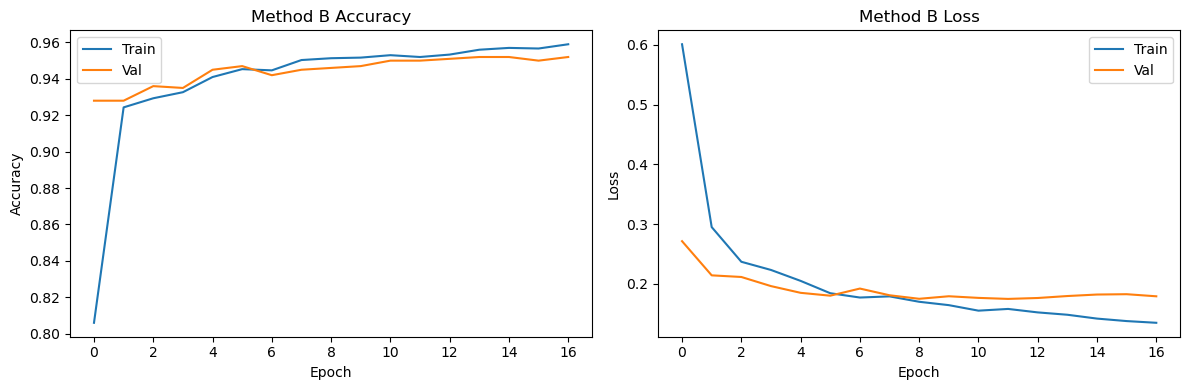

In [22]:
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_dual.history['accuracy'], label='Train')
plt.plot(history_dual.history['val_accuracy'], label='Val')
plt.title("Method B Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_dual.history['loss'], label='Train')
plt.plot(history_dual.history['val_loss'], label='Val')
plt.title("Method B Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()
